# CatBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import Pool
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix

## 1. 데이터 로드

In [2]:
# 데이터 로드
X = pd.read_csv('../../../data/preprocessed/cell2cell_train.csv')
y = pd.read_csv('../../../data/preprocessed/cell2cell_train_churn.csv')

X.drop('CustomerID', axis=1)

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Occ_Clerical,Occ_Crafts,Occ_Homemaker,Occ_Other,Occ_Professional,Occ_Retired,Occ_Self,Occ_Student,Marital_No,Marital_Yes
0,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,...,0,0,0,0,1,0,0,0,1,0
1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,...,0,0,0,0,1,0,0,0,0,1
2,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
3,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,...,0,0,0,1,0,0,0,0,1,0
4,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49771,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,5.7,1.0,...,0,0,0,0,1,0,0,0,1,0
49772,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,0.7,0.0,...,0,0,0,1,0,0,0,0,0,1
49773,71.99,724.0,70.0,0.00,4.0,0.9,-40.0,-2.0,14.3,1.0,...,0,0,0,0,1,0,0,0,0,0
49774,117.49,384.0,30.0,0.00,250.0,0.0,0.0,0.0,4.0,1.0,...,0,0,0,0,1,0,0,0,0,1


## 2. 데이터 분리 및 모델 훈련용 전처리

In [3]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.3)

In [4]:
# 연속형 변수, 범주형 변수 구분
numeric_features = [
    'MonthlyRevenue', 'TotalRecurringCharge', 'PercChangeRevenues',
    'MonthlyMinutes', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes',
    'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
    'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
    'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls',
    'CallWaitingCalls', 'DirectorAssistedCalls', 'MonthsInService', 'CurrentEquipmentDays',
    'AgeHH1', 'AgeHH2'
]


cat_features = [
    'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 
    'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 
    'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 
    'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 
    'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 
    'AdjustmentsToCreditRating', 'HandsetPrice', 'MadeCallToRetentionTeam', 
    'CreditRating', 'Prizm_Other', 'Prizm_Rural', 'Prizm_Suburban', 'Prizm_Town', 
    'Occ_Clerical', 'Occ_Crafts', 'Occ_Homemaker', 'Occ_Other', 'Occ_Professional', 
    'Occ_Retired', 'Occ_Self', 'Occ_Student', 'Marital_No', 'Marital_Yes',
    'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels'
]

In [5]:
# 범주형 변수 데이터 타입 변환 (int로 통일)
for col in cat_features:
    X_train[col] = X_train[col].astype(int)

for col in cat_features:
    X_test[col] = X_test[col].astype(int)

In [6]:
# Pool 형태로 변환
X_train_pool = Pool(X_train, y_train, cat_features=cat_features)
X_test_pool = Pool(X_test, y_test, cat_features=cat_features)

## 3. 모델 학습

In [7]:
cb_clf = CatBoostClassifier(
    n_estimators=1000,
    depth=5,
    learning_rate=0.03,
    loss_function='CrossEntropy',
    eval_metric='AUC'
)

cb_clf.fit(X_train_pool, eval_set=[X_train_pool, X_test_pool], verbose=100, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5903816	test1: 0.5893942	best: 0.5893942 (0)	total: 233ms	remaining: 3m 52s
100:	test: 0.6634395	test1: 0.6536247	best: 0.6536247 (100)	total: 6.57s	remaining: 58.5s
200:	test: 0.6826941	test1: 0.6649007	best: 0.6649007 (200)	total: 12.7s	remaining: 50.6s
300:	test: 0.6938502	test1: 0.6699159	best: 0.6699159 (300)	total: 18.8s	remaining: 43.8s
400:	test: 0.7043771	test1: 0.6738413	best: 0.6738413 (400)	total: 24.8s	remaining: 37s
500:	test: 0.7165740	test1: 0.6778077	best: 0.6778537 (498)	total: 30.9s	remaining: 30.7s
600:	test: 0.7251039	test1: 0.6799997	best: 0.6800038 (598)	total: 36.9s	remaining: 24.5s
700:	test: 0.7323774	test1: 0.6812823	best: 0.6812823 (700)	total: 42.9s	remaining: 18.3s
800:	test: 0.7390953	test1: 0.6822133	best: 0.6822403 (797)	total: 49.3s	remaining: 12.2s
900:	test: 0.7460425	test1: 0.6827146	best: 0.6827146 (900)	total: 55.8s	remaining: 6.13s
999:	test: 0.7518120	test1: 0.6831665	best: 0.6831728 (998)	total: 1m 1s	remaining: 0us

bestTest = 0.683

CatBoostClassifier(depth=5, eval_metric='AUC', learning_rate=0.03, loss_function='CrossEntropy', n_estimators=1000)

## 4. 모델 평가

##### 정확도

In [8]:
print("Train Accuarcy Score is :", cb_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", cb_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.7433917860115374
Test Accuarcy Score is  : 0.7272483760798232


##### Confusion Matrix

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# 모델 예측 결과 확인
y_pred = cb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.97      0.84     10656
           1       0.63      0.12      0.20      4277

    accuracy                           0.73     14933
   macro avg       0.68      0.54      0.52     14933
weighted avg       0.70      0.73      0.65     14933



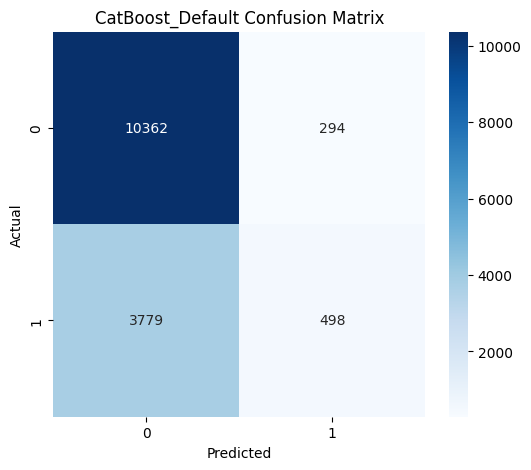

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoost_Default Confusion Matrix')

plt.savefig('../../../asset/graph/catboost/CatBoost_Default_Confusion_Matrix.png', dpi=300, bbox_inches='tight')

plt.show()

##### ROC-AUC 커브

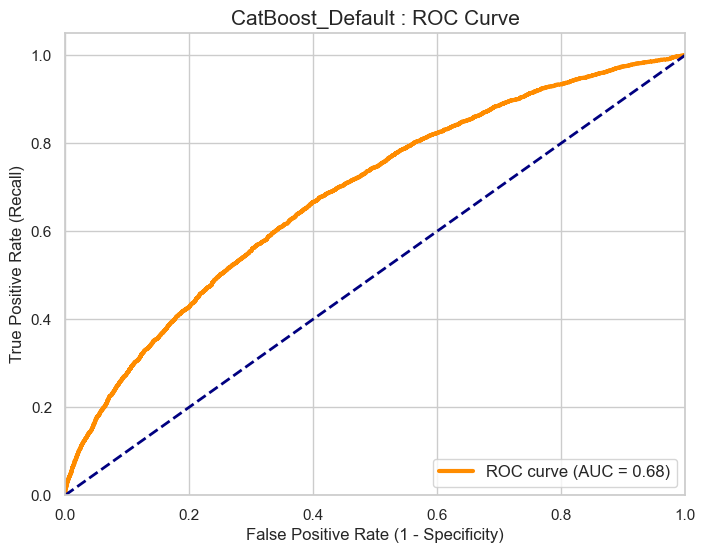

0.683172826789848


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

pred_proba = cb_clf.predict_proba(X_test)

# 스타일 설정
sns.set_theme(style="whitegrid")

# ROC 계산
fpr, tpr, thresholds = roc_curve(y_test, pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 범위 및 라벨 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('CatBoost_Default : ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('../../../asset/graph/catboost/CatBoost_Default_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(roc_auc)

##### Feature 중요도 출력

In [12]:
cb_clf.feature_importances_

fesat_impt_ser = pd.Series(cb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fesat_impt_ser

MonthsInService         12.865279
CurrentEquipmentDays     9.797725
PercChangeMinutes        8.134715
MonthlyMinutes           7.823207
TotalRecurringCharge     5.923474
                          ...    
Occ_Homemaker            0.018724
Occ_Clerical             0.017432
Occ_Student              0.015570
NonUSTravel              0.006248
OwnsMotorcycle           0.000000
Length: 66, dtype: float64

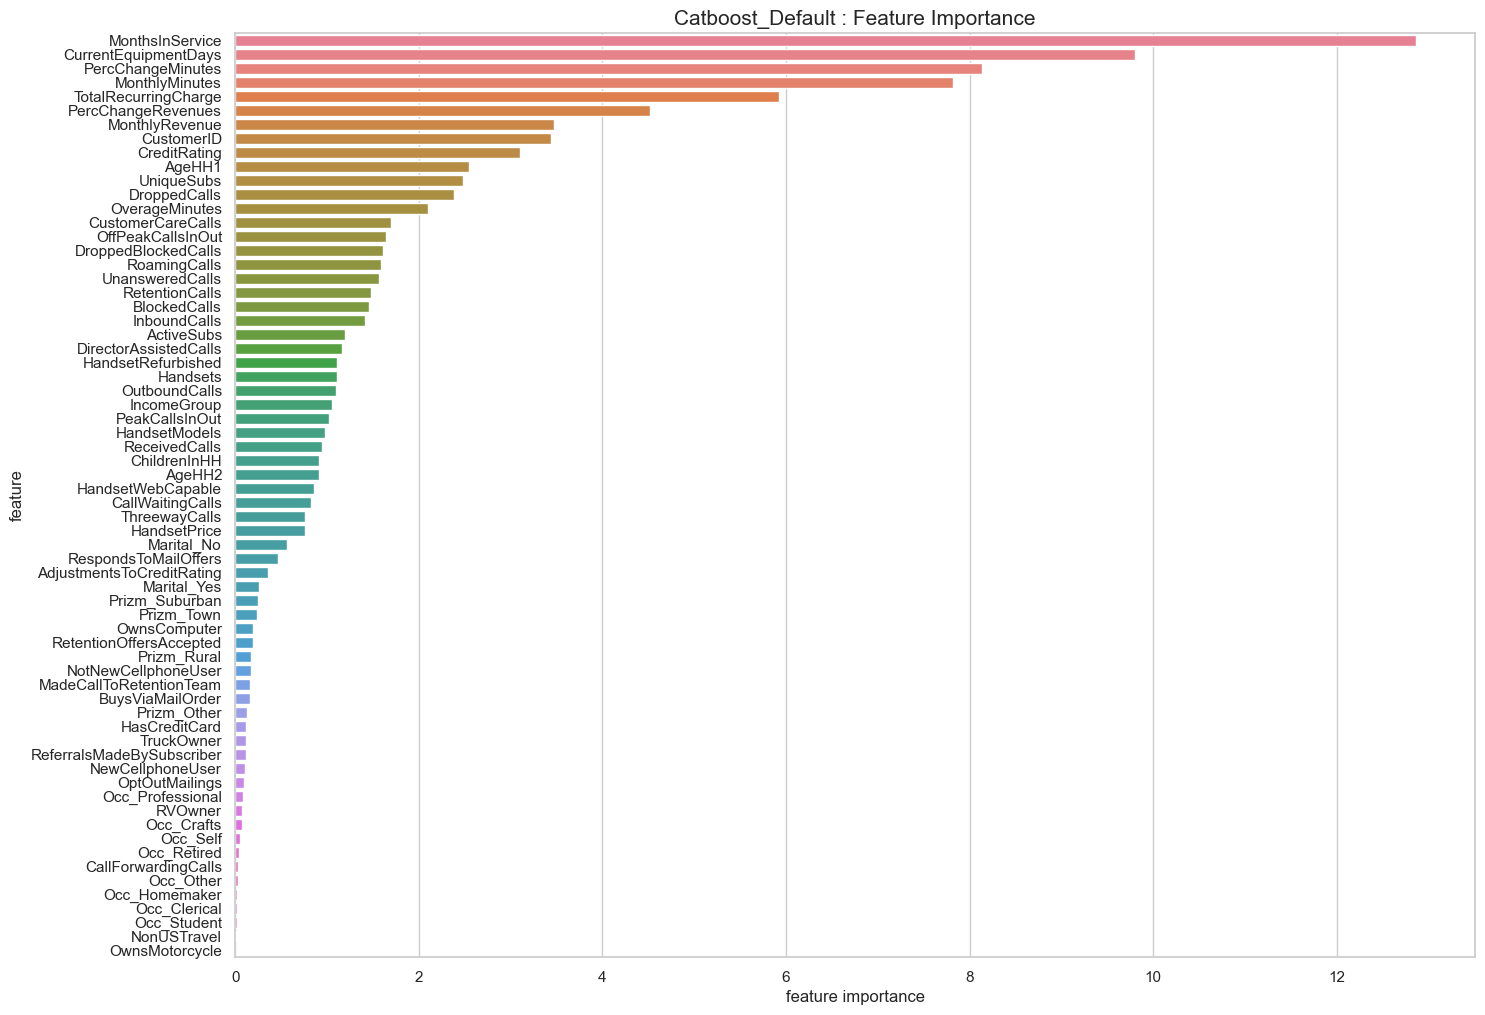

In [13]:
plt.figure(figsize=(16,12))
sns.barplot(
    x=fesat_impt_ser,
    y=fesat_impt_ser.index,
    hue=fesat_impt_ser.index,
)
plt.xlabel('feature importance')
plt.ylabel('feature')
plt.title('Catboost_Default : Feature Importance', fontsize=15)

plt.savefig('../../../asset/graph/catboost/Catboost_Default_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

## [L1 규제 대체] Feature를 줄여가며 학습한 결과

##### Feature 66개 -> 40개

In [14]:
# 피처 선택 실행
summary = cb_clf.select_features(
    X_train_pool,
    eval_set=X_test_pool,
    features_for_select='0-65',    # 선택 대상 피처 범위 (또는 컬럼명 리스트)
    num_features_to_select=40,     # 최종적으로 남길 피처 개수
    steps=3,                       # 몇 번에 걸쳐 제거할지 (높을수록 정교함)
    algorithm='RecursiveByShapValues', # SHAP 값을 기준으로 재귀적 제거
    train_final_model=False,       # 여기서 바로 최종 모델을 학습할지 여부
    logging_level='Verbose'
)

Step #1 out of 3
0:	test: 0.5826990	best: 0.5826990 (0)	total: 61.1ms	remaining: 1m 1s
1:	test: 0.6003669	best: 0.6003669 (1)	total: 134ms	remaining: 1m 6s
2:	test: 0.6032884	best: 0.6032884 (2)	total: 200ms	remaining: 1m 6s
3:	test: 0.6037117	best: 0.6037117 (3)	total: 261ms	remaining: 1m 4s
4:	test: 0.6221608	best: 0.6221608 (4)	total: 324ms	remaining: 1m 4s
5:	test: 0.6241025	best: 0.6241025 (5)	total: 375ms	remaining: 1m 2s
6:	test: 0.6263376	best: 0.6263376 (6)	total: 438ms	remaining: 1m 2s
7:	test: 0.6272034	best: 0.6272034 (7)	total: 502ms	remaining: 1m 2s
8:	test: 0.6276005	best: 0.6276005 (8)	total: 568ms	remaining: 1m 2s
9:	test: 0.6269591	best: 0.6276005 (8)	total: 620ms	remaining: 1m 1s
10:	test: 0.6273951	best: 0.6276005 (8)	total: 667ms	remaining: 60s
11:	test: 0.6286376	best: 0.6286376 (11)	total: 713ms	remaining: 58.7s
12:	test: 0.6299298	best: 0.6299298 (12)	total: 756ms	remaining: 57.4s
13:	test: 0.6306284	best: 0.6306284 (13)	total: 807ms	remaining: 56.8s
14:	test: 0

##### Feature 66개 -> 30개

In [15]:
# 피처 선택 실행
summary = cb_clf.select_features(
    X_train_pool,
    eval_set=X_test_pool,
    features_for_select='0-65',    # 선택 대상 피처 범위 (또는 컬럼명 리스트)
    num_features_to_select=30,     # 최종적으로 남길 피처 개수
    steps=3,                       # 몇 번에 걸쳐 제거할지 (높을수록 정교함)
    algorithm='RecursiveByShapValues', # SHAP 값을 기준으로 재귀적 제거
    train_final_model=False,       # 여기서 바로 최종 모델을 학습할지 여부
    logging_level='Verbose'
)

Step #1 out of 3
0:	test: 0.5826990	best: 0.5826990 (0)	total: 42ms	remaining: 41.9s
1:	test: 0.6003669	best: 0.6003669 (1)	total: 91.4ms	remaining: 45.6s
2:	test: 0.6032884	best: 0.6032884 (2)	total: 140ms	remaining: 46.5s
3:	test: 0.6037117	best: 0.6037117 (3)	total: 186ms	remaining: 46.2s
4:	test: 0.6221608	best: 0.6221608 (4)	total: 237ms	remaining: 47.1s
5:	test: 0.6241025	best: 0.6241025 (5)	total: 291ms	remaining: 48.2s
6:	test: 0.6263376	best: 0.6263376 (6)	total: 335ms	remaining: 47.6s
7:	test: 0.6272034	best: 0.6272034 (7)	total: 382ms	remaining: 47.3s
8:	test: 0.6276005	best: 0.6276005 (8)	total: 437ms	remaining: 48.1s
9:	test: 0.6269591	best: 0.6276005 (8)	total: 493ms	remaining: 48.8s
10:	test: 0.6273951	best: 0.6276005 (8)	total: 538ms	remaining: 48.4s
11:	test: 0.6286376	best: 0.6286376 (11)	total: 588ms	remaining: 48.4s
12:	test: 0.6299298	best: 0.6299298 (12)	total: 642ms	remaining: 48.8s
13:	test: 0.6306284	best: 0.6306284 (13)	total: 692ms	remaining: 48.7s
14:	test: 

##### Feature 66개 -> 20개

In [16]:
# 피처 선택 실행
summary = cb_clf.select_features(
    X_train_pool,
    eval_set=X_test_pool,
    features_for_select='0-65',    # 선택 대상 피처 범위 (또는 컬럼명 리스트)
    num_features_to_select=20,     # 최종적으로 남길 피처 개수
    steps=5,                       # 몇 번에 걸쳐 제거할지 (높을수록 정교함)
    algorithm='RecursiveByShapValues', # SHAP 값을 기준으로 재귀적 제거
    train_final_model=False,       # 여기서 바로 최종 모델을 학습할지 여부
    logging_level='Verbose'
)

Step #1 out of 5
0:	test: 0.5826990	best: 0.5826990 (0)	total: 65.6ms	remaining: 1m 5s
1:	test: 0.6003669	best: 0.6003669 (1)	total: 132ms	remaining: 1m 5s
2:	test: 0.6032884	best: 0.6032884 (2)	total: 189ms	remaining: 1m 2s
3:	test: 0.6037117	best: 0.6037117 (3)	total: 257ms	remaining: 1m 4s
4:	test: 0.6221608	best: 0.6221608 (4)	total: 308ms	remaining: 1m 1s
5:	test: 0.6241025	best: 0.6241025 (5)	total: 355ms	remaining: 58.9s
6:	test: 0.6263376	best: 0.6263376 (6)	total: 421ms	remaining: 59.7s
7:	test: 0.6272034	best: 0.6272034 (7)	total: 480ms	remaining: 59.5s
8:	test: 0.6276005	best: 0.6276005 (8)	total: 535ms	remaining: 58.9s
9:	test: 0.6269591	best: 0.6276005 (8)	total: 598ms	remaining: 59.2s
10:	test: 0.6273951	best: 0.6276005 (8)	total: 654ms	remaining: 58.8s
11:	test: 0.6286376	best: 0.6286376 (11)	total: 713ms	remaining: 58.7s
12:	test: 0.6299298	best: 0.6299298 (12)	total: 769ms	remaining: 58.4s
13:	test: 0.6306284	best: 0.6306284 (13)	total: 825ms	remaining: 58.1s
14:	test:

In [17]:
summary['eliminated_features_names']

['IncomeGroup',
 'AgeHH2',
 'Handsets',
 'Prizm_Other',
 'ThreewayCalls',
 'RetentionOffersAccepted',
 'ReferralsMadeBySubscriber',
 'OwnsMotorcycle',
 'Occ_Self',
 'HasCreditCard',
 'NonUSTravel',
 'OptOutMailings',
 'NewCellphoneUser',
 'Occ_Other',
 'HandsetModels',
 'CallWaitingCalls',
 'BlockedCalls',
 'Occ_Homemaker',
 'Occ_Student',
 'Occ_Clerical',
 'ReceivedCalls',
 'Occ_Crafts',
 'Occ_Retired',
 'Occ_Professional',
 'RVOwner',
 'ChildrenInHH',
 'CallForwardingCalls',
 'TruckOwner',
 'NotNewCellphoneUser',
 'BuysViaMailOrder',
 'OwnsComputer',
 'Marital_Yes',
 'HandsetPrice',
 'DirectorAssistedCalls',
 'CustomerID',
 'UnansweredCalls',
 'AdjustmentsToCreditRating',
 'Prizm_Town',
 'Prizm_Rural',
 'CustomerCareCalls',
 'Prizm_Suburban',
 'OutboundCalls',
 'Marital_No',
 'RespondsToMailOffers',
 'UniqueSubs',
 'ActiveSubs']